# Mini-Lab: Logistic Regression and SVMs
## BRFSS 2015 Diabetes Health Indicators

**Team:** Harvey, Sydney, Wolfgang, Nashita

We predict whether a survey respondent has diagnosed diabetes from 18 health,
lifestyle, and demographic indicators, using logistic regression and support
vector machines. 

# 1. Setup and Data Loading

In [1]:
# Settings used throughout the notebook
SEED = 42
TARGET_RECALL = 0.85   # share of diabetics the tuned models must catch
BETA = 2               # F-beta used for tuning: beta=2 weights recall 4x precision
C_NO, C_PRE, C_DIA = "#7f9bb0", "#e0a458", "#8c2f5f"   # same colors as the main notebook

import warnings
warnings.filterwarnings("ignore")

import os, time
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)
print("numpy and pandas loaded.")

numpy and pandas loaded.


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_val_predict)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score,
                             precision_score, f1_score, fbeta_score, make_scorer,
                             roc_auc_score, average_precision_score,
                             confusion_matrix, precision_recall_curve)
print("scikit-learn loaded.")

scikit-learn loaded.


In [3]:
# Plotting setup. If this cell errors with "No module named 'matplotlib'",
# run  %pip install matplotlib  in a new cell, then restart the kernel.
import matplotlib.pyplot as plt

for style in ("seaborn-v0_8-whitegrid", "seaborn-whitegrid", "ggplot"):
    if style in plt.style.available:
        plt.style.use(style)
        break
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.titleweight"] = "600"
print("matplotlib loaded.")

matplotlib loaded.


In [4]:
raw = pd.read_csv("diabetes_012_health_indicators_BRFSS2015 (1).csv")

print(f"rows    : {raw.shape[0]:,}")
print(f"columns : {raw.shape[1]}")

rows    : 253,680
columns : 22


# 2. Data Preparation

**Target.** The raw column `Diabetes_012` has three classes: 0 = no diabetes,
1 = prediabetes, 2 = diabetes. We collapse it to a binary target,
`Diabetes_binary` = 1 for diagnosed diabetes (class 2) and 0 otherwise.
Prediabetes (about 1.8% of rows) joins the negative class. Our EDA showed it has
no profile of its own, and it is too small to model reliably as a third class.

**Features.** We use 18 of the 21 indicators. We drop the three healthcare-access
variables (`CholCheck`, `AnyHealthcare`, `NoDocbcCost`). These measure whether
someone has contact with the healthcare system, and so whether they *could* be
diagnosed, rather than whether they have diabetes. Keeping them would teach the
model who gets diagnosed, not who is sick.

**Assumptions.**

1. The self-reported diagnosis is the ground truth. Undiagnosed diabetics sit in
   the negative class, so recall is measured against *known* cases.
2. Rows are independent. Exact duplicate rows are kept: with only coarse coded
   answers, identical profiles are expected from different people, and removing
   them would distort the class balance (EDA Section 4.2).
3. Ordinal codes (`GenHlth`, `Age`, `Education`, `Income`) are treated as
   numeric. That assumes each step up the scale has a similar effect, which is
   reasonable for these evenly spaced scales and keeps the weights easy to read.
4. All features are standardized (mean 0, SD 1). SVMs need this because
   they are distance-based, and it puts the logistic regression weights on a
   comparable per-standard-deviation scale. The scaler is fit on training data
   only, inside each pipeline, so no test information leaks into training.

In [5]:
raw["Diabetes_binary"] = (raw["Diabetes_012"] == 2).astype(int)
TARGET = "Diabetes_binary"

ACCESS = ["CholCheck", "AnyHealthcare", "NoDocbcCost"]
X = raw.drop(columns=["Diabetes_012", TARGET] + ACCESS)
y = raw[TARGET]

print(f"Prevalence of diagnosed diabetes: {100*y.mean():.2f}%")
print(f"Features used ({X.shape[1]}): {', '.join(X.columns)}")

Prevalence of diagnosed diabetes: 13.93%
Features used (18): HighBP, HighChol, BMI, Smoker, Stroke, HeartDiseaseorAttack, PhysActivity, Fruits, Veggies, HvyAlcoholConsump, GenHlth, MentHlth, PhysHlth, DiffWalk, Sex, Age, Education, Income


### 80/20 train/test split

80% of rows are used for training and 20% are held out
for testing. The split is stratified so both sides have the same diabetes
rate. All tuning (hyperparameters and thresholds) uses 5-fold cross-validation
inside the training set. 

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
f2_scorer = make_scorer(fbeta_score, beta=BETA)

print(f"Training rows: {len(X_train):,}   diabetes rate {y_train.mean():.3f}")
print(f"Test rows:     {len(X_test):,}    diabetes rate {y_test.mean():.3f}")

Training rows: 202,944   diabetes rate 0.139
Test rows:     50,736    diabetes rate 0.139


In [7]:
# Helpers used by every model below
results, timings = [], []

def evaluate(name, score, pred, threshold):
    """Test-set metrics. `score` is a probability (LR) or decision value (SVM)."""
    results.append({
        "Model": name, "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, pred),
        "Balanced acc": balanced_accuracy_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred),
        "F2": fbeta_score(y_test, pred, beta=BETA),
        "ROC-AUC": roc_auc_score(y_test, score),
        "PR-AUC": average_precision_score(y_test, score),
    })

def pick_threshold(y_true, oof_score, target=TARGET_RECALL):
    """Highest threshold whose out-of-fold recall still reaches the target."""
    prec, rec, thr = precision_recall_curve(y_true, oof_score)
    prec, rec = prec[:-1], rec[:-1]
    i = np.where(rec >= target)[0][-1]
    return thr[i], rec[i], prec[i], (prec, rec, thr)

def timed_fit(name, model, X_, y_):
    t0 = time.perf_counter()
    model.fit(X_, y_)
    fit_s = time.perf_counter() - t0
    t0 = time.perf_counter()
    _ = model.predict(X_test)
    pred_s = time.perf_counter() - t0
    timings.append({"Model": name, "Training rows": len(X_), "Fit time (s)": fit_s,
                    "Predict time, test set (s)": pred_s})
    return model

# 3. Logistic Regression

## 3.1 Reference points

First, two reference points. "Predict nobody" sets the accuracy floor. The
default logistic regression (no class weighting, 0.50 threshold) is the
untuned model we have to improve on.

In [8]:
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
evaluate("Predict nobody has diabetes", dummy.predict_proba(X_test)[:, 1],
         dummy.predict(X_test), 0.5)

lr_default = timed_fit("Logistic regression, default",
                       make_pipeline(StandardScaler(),
                                     LogisticRegression(max_iter=1000, random_state=SEED)),
                       X_train, y_train)
p = lr_default.predict_proba(X_test)[:, 1]
evaluate("Logistic regression, default (0.50)", p, (p >= 0.5).astype(int), 0.5)

pd.DataFrame(results).set_index("Model").round(3)

,Threshold,Accuracy,Balanced acc,Recall,Precision,F1,F2,ROC-AUC,PR-AUC
Model,,,,,,,,,
Predict nobody has diabetes,0.500,0.861,0.500,0.000,0.000,0.000,0.000,0.500,0.139
"Logistic regression, default (0.50)",0.500,0.862,0.567,0.157,0.518,0.242,0.183,0.818,0.393


## 3.2 Tuning the parameters for recall

We search over three parameters:

* **`C`**, the inverse regularization strength. Smaller values shrink the
  weights more.
* **`penalty`**: L2 shrinks all weights smoothly, while L1 can set weak ones to
  exactly zero, which acts as feature selection.
* **`class_weight`**, how much more a missed diabetic costs than a false alarm.
  "balanced" weights each class by the inverse of its frequency (about 6× for
  diabetics), and we also try 1.5× and 2× that.

Each combination is scored by 5-fold cross-validated F2 on the training set.

In [9]:
neg_pos = float((y_train == 0).sum() / (y_train == 1).sum())
CLASS_WEIGHTS = ["balanced",
                 {0: 1, 1: round(neg_pos * 1.5, 2)},
                 {0: 1, 1: round(neg_pos * 2.0, 2)}]

lr_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()),
              ("clf", LogisticRegression(solver="liblinear", max_iter=2000,
                                         random_state=SEED))]),
    {"clf__C": [0.01, 0.1, 1, 10],
     "clf__penalty": ["l1", "l2"],
     "clf__class_weight": CLASS_WEIGHTS},
    cv=cv, n_jobs=-1, refit="f2",
    scoring={"f2": f2_scorer, "recall": "recall", "precision": "precision"})

t0 = time.perf_counter()
lr_grid.fit(X_train, y_train)
lr_search_s = time.perf_counter() - t0

def grid_table(grid, params):
    d = pd.DataFrame(grid.cv_results_)
    out = pd.DataFrame({p.split("__")[1]: d[f"param_{p}"].astype(str) for p in params})
    out["CV F2"] = d["mean_test_f2"]
    out["CV recall"] = d["mean_test_recall"]
    out["CV precision"] = d["mean_test_precision"]
    out["Fit time per fold (s)"] = d["mean_fit_time"]
    return out.sort_values("CV F2", ascending=False)

print(f"Grid search time: {lr_search_s:.1f} s")
print("Best logistic regression parameters:", lr_grid.best_params_)
grid_table(lr_grid, ["clf__C", "clf__penalty", "clf__class_weight"]).head(8).round(3)

Grid search time: 42.3 s
Best logistic regression parameters: {'clf__C': 0.01, 'clf__class_weight': {0: 1, 1: 9.27}, 'clf__penalty': 'l2'}


,C,penalty,class_weight,CV F2,CV recall,CV precision,Fit time per fold (s)
3,0.01,l2,"{0: 1, 1: 9.27}",0.600,0.852,0.274,2.079
2,0.01,l1,"{0: 1, 1: 9.27}",0.600,0.853,0.274,2.010
8,0.1,l1,"{0: 1, 1: 9.27}",0.600,0.852,0.275,2.302
15,1.0,l2,"{0: 1, 1: 9.27}",0.600,0.852,0.275,2.237
21,10.0,l2,"{0: 1, 1: 9.27}",0.600,0.852,0.275,1.785
14,1.0,l1,"{0: 1, 1: 9.27}",0.600,0.852,0.275,2.176
20,10.0,l1,"{0: 1, 1: 9.27}",0.600,0.852,0.275,2.147
9,0.1,l2,"{0: 1, 1: 9.27}",0.600,0.852,0.275,2.048


## 3.3 Choosing the decision threshold

Changing the class weight moves the model along its precision/recall tradeoff,
and the threshold fine-tunes where it lands. To choose the threshold without
touching the test set, every training row gets an out-of-fold probability
from a model that never saw it. We then take the highest threshold whose
out-of-fold recall is at least `TARGET_RECALL`.

In [10]:
lr_best = lr_grid.best_estimator_
lr_oof = cross_val_predict(lr_best, X_train, y_train, cv=cv,
                           method="predict_proba", n_jobs=-1)[:, 1]
lr_thr, r_, p_, lr_curve = pick_threshold(y_train, lr_oof)
print(f"Logistic regression threshold: {lr_thr:.3f} "
      f"(out-of-fold recall {r_:.3f}, precision {p_:.3f})")

lr_best = timed_fit("Logistic regression, tuned", lr_best, X_train, y_train)
p_lr = lr_best.predict_proba(X_test)[:, 1]
evaluate("Logistic regression, tuned for recall", p_lr, (p_lr >= lr_thr).astype(int), lr_thr)
pd.DataFrame(results).set_index("Model").round(3)

Logistic regression threshold: 0.503 (out-of-fold recall 0.850, precision 0.276)


,Threshold,Accuracy,Balanced acc,Recall,Precision,F1,F2,ROC-AUC,PR-AUC
Model,,,,,,,,,
Predict nobody has diabetes,0.500,0.861,0.500,0.000,0.000,0.000,0.000,0.500,0.139
"Logistic regression, default (0.50)",0.500,0.862,0.567,0.157,0.518,0.242,0.183,0.818,0.393
"Logistic regression, tuned for recall",0.503,0.667,0.743,0.847,0.275,0.415,0.598,0.818,0.391


# 4. Support Vector Machines

There are about 200,000 training rows. An RBF-kernel SVM on the full
training set is impractical. As the assignment allows, we use two approaches:

1. Linear SVM on the full training set (`LinearSVC`), tuned for recall in the
   same way as the logistic regression. 
2. RBF-kernel SVM on a 20,000-row subsample of the training set.

Both SVMs output a decision value (signed distance from the boundary)
rather than a probability. The threshold is set on that decision value.

## 4.1 Linear SVM (full training set)

We tune `C` and `class_weight` by 5-fold cross-validated F2, as for the
logistic regression. For an SVM, `C` is the penalty on points that fall on the
wrong side of the margin. A small `C` gives a wider, softer margin that
tolerates more violations; a large `C` fits the training data more tightly.

In [11]:
svm_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()),
              ("clf", LinearSVC(dual=False, max_iter=5000, random_state=SEED))]),
    {"clf__C": [0.001, 0.01, 0.1, 1],
     "clf__class_weight": CLASS_WEIGHTS},
    cv=cv, n_jobs=-1, refit="f2",
    scoring={"f2": f2_scorer, "recall": "recall", "precision": "precision"})

t0 = time.perf_counter()
svm_grid.fit(X_train, y_train)
svm_search_s = time.perf_counter() - t0

print(f"Grid search time: {svm_search_s:.1f} s")
print("Best linear SVM parameters:", svm_grid.best_params_)
grid_table(svm_grid, ["clf__C", "clf__class_weight"]).head(8).round(3)

Grid search time: 16.9 s
Best linear SVM parameters: {'clf__C': 0.001, 'clf__class_weight': {0: 1, 1: 9.27}}


,C,class_weight,CV F2,CV recall,CV precision,Fit time per fold (s)
1,0.001,"{0: 1, 1: 9.27}",0.598,0.855,0.272,1.945
7,0.1,"{0: 1, 1: 9.27}",0.598,0.855,0.272,1.726
4,0.01,"{0: 1, 1: 9.27}",0.598,0.855,0.272,2.025
10,1.0,"{0: 1, 1: 9.27}",0.598,0.855,0.272,1.860
9,1.0,balanced,0.593,0.769,0.309,2.162
6,0.1,balanced,0.593,0.769,0.309,2.115
0,0.001,balanced,0.593,0.769,0.309,1.950
3,0.01,balanced,0.593,0.769,0.309,1.738


In [12]:
svm_best = svm_grid.best_estimator_
svm_oof = cross_val_predict(svm_best, X_train, y_train, cv=cv,
                            method="decision_function", n_jobs=-1)
svm_thr, r_, p_, svm_curve = pick_threshold(y_train, svm_oof)
print(f"Linear SVM threshold (decision value): {svm_thr:.3f} "
      f"(out-of-fold recall {r_:.3f}, precision {p_:.3f})")

svm_best = timed_fit("Linear SVM (LinearSVC), tuned", svm_best, X_train, y_train)
d_svm = svm_best.decision_function(X_test)
evaluate("Linear SVM, tuned for recall", d_svm, (d_svm >= svm_thr).astype(int), svm_thr)

Linear SVM threshold (decision value): 0.011 (out-of-fold recall 0.850, precision 0.274)


## 4.2 RBF-kernel SVM (20,000-row subsample)

The RBF kernel lets the boundary curve. Its extra parameter, `gamma`, sets how
far each training point's influence reaches: a small `gamma` gives a smooth
boundary, and a large one gives a wiggly boundary that can overfit. We tune
`C` and `gamma` by 3-fold cross-validated F2 on the subsample, with balanced
class weights.

In [13]:
SUB_N = 20_000
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=SUB_N,
                                      random_state=SEED, stratify=y_train)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

rbf_grid = GridSearchCV(
    Pipeline([("scale", StandardScaler()),
              ("clf", SVC(kernel="rbf", class_weight="balanced", random_state=SEED))]),
    {"clf__C": [0.1, 1, 10], "clf__gamma": ["scale", 0.01, 0.1]},
    cv=cv3, n_jobs=-1, refit="f2",
    scoring={"f2": f2_scorer, "recall": "recall", "precision": "precision"})

t0 = time.perf_counter()
rbf_grid.fit(X_sub, y_sub)
rbf_search_s = time.perf_counter() - t0

print(f"Grid search time on {SUB_N:,} rows: {rbf_search_s:.1f} s")
print("Best RBF SVM parameters:", rbf_grid.best_params_)
grid_table(rbf_grid, ["clf__C", "clf__gamma"]).round(3)

Grid search time on 20,000 rows: 140.2 s
Best RBF SVM parameters: {'clf__C': 1, 'clf__gamma': 0.01}


,C,gamma,CV F2,CV recall,CV precision,Fit time per fold (s)
4,1.0,0.01,0.596,0.810,0.290,18.666
0,0.1,scale,0.594,0.811,0.287,20.138
1,0.1,0.01,0.593,0.800,0.291,21.033
7,10.0,0.01,0.592,0.795,0.293,16.902
2,0.1,0.1,0.590,0.817,0.279,21.450
3,1.0,scale,0.573,0.739,0.301,17.149
5,1.0,0.1,0.534,0.656,0.307,16.414
6,10.0,scale,0.471,0.551,0.297,23.417
8,10.0,0.1,0.388,0.423,0.290,15.404


In [14]:
rbf_best = rbf_grid.best_estimator_
rbf_oof = cross_val_predict(rbf_best, X_sub, y_sub, cv=cv3,
                            method="decision_function", n_jobs=-1)
rbf_thr, r_, p_, _ = pick_threshold(y_sub, rbf_oof)
print(f"RBF SVM threshold (decision value): {rbf_thr:.3f} "
      f"(out-of-fold recall {r_:.3f}, precision {p_:.3f})")

rbf_best = timed_fit("RBF SVM (20k subsample), tuned", rbf_best, X_sub, y_sub)
d_rbf = rbf_best.decision_function(X_test)
evaluate("RBF SVM (20k rows), tuned for recall", d_rbf, (d_rbf >= rbf_thr).astype(int), rbf_thr)

# For a fair comparison: logistic regression trained on the same 20k rows
lr_sub = Pipeline([("scale", StandardScaler()),
                   ("clf", LogisticRegression(**{k.split("__")[1]: v for k, v in
                                                 lr_grid.best_params_.items()},
                                              solver="liblinear", max_iter=2000,
                                              random_state=SEED))])
lr_sub_oof = cross_val_predict(lr_sub, X_sub, y_sub, cv=cv3, method="predict_proba")[:, 1]
lr_sub_thr, *_ = pick_threshold(y_sub, lr_sub_oof)
lr_sub = timed_fit("Logistic regression (20k subsample), tuned", lr_sub, X_sub, y_sub)
p_sub = lr_sub.predict_proba(X_test)[:, 1]
evaluate("Logistic regression (20k rows), tuned for recall", p_sub,
         (p_sub >= lr_sub_thr).astype(int), lr_sub_thr)

RBF SVM threshold (decision value): -0.145 (out-of-fold recall 0.850, precision 0.279)


# 5. Evaluation: Comparing the Models on the Test Set

In [15]:
comparison = pd.DataFrame(results).set_index("Model")
comparison.round(3)

,Threshold,Accuracy,Balanced acc,Recall,Precision,F1,F2,ROC-AUC,PR-AUC
Model,,,,,,,,,
Predict nobody has diabetes,0.500,0.861,0.500,0.000,0.000,0.000,0.000,0.500,0.139
"Logistic regression, default (0.50)",0.500,0.862,0.567,0.157,0.518,0.242,0.183,0.818,0.393
"Logistic regression, tuned for recall",0.503,0.667,0.743,0.847,0.275,0.415,0.598,0.818,0.391
"Linear SVM, tuned for recall",0.011,0.665,0.742,0.849,0.274,0.414,0.598,0.818,0.391
"RBF SVM (20k rows), tuned for recall",-0.145,0.667,0.743,0.847,0.275,0.415,0.598,0.818,0.389
"Logistic regression (20k rows), tuned for recall",0.501,0.664,0.741,0.848,0.273,0.413,0.596,0.817,0.390


In [16]:
timing_table = pd.DataFrame(timings).set_index("Model")
timing_table.loc["Logistic regression, tuned", "Grid search time (s)"] = lr_search_s
timing_table.loc["Linear SVM (LinearSVC), tuned", "Grid search time (s)"] = svm_search_s
timing_table.loc["RBF SVM (20k subsample), tuned", "Grid search time (s)"] = rbf_search_s
timing_table.round(3)

,Training rows,Fit time (s),"Predict time, test set (s)",Grid search time (s)
Model,,,,
"Logistic regression, default",202944,0.314,0.016,NaN
"Logistic regression, tuned",202944,0.669,0.012,42.275
"Linear SVM (LinearSVC), tuned",202944,0.652,0.014,16.920
"RBF SVM (20k subsample), tuned",20000,20.415,87.877,140.231
"Logistic regression (20k subsample), tuned",20000,0.043,0.012,NaN


findfont: Failed to find font weight 600, now using 700.


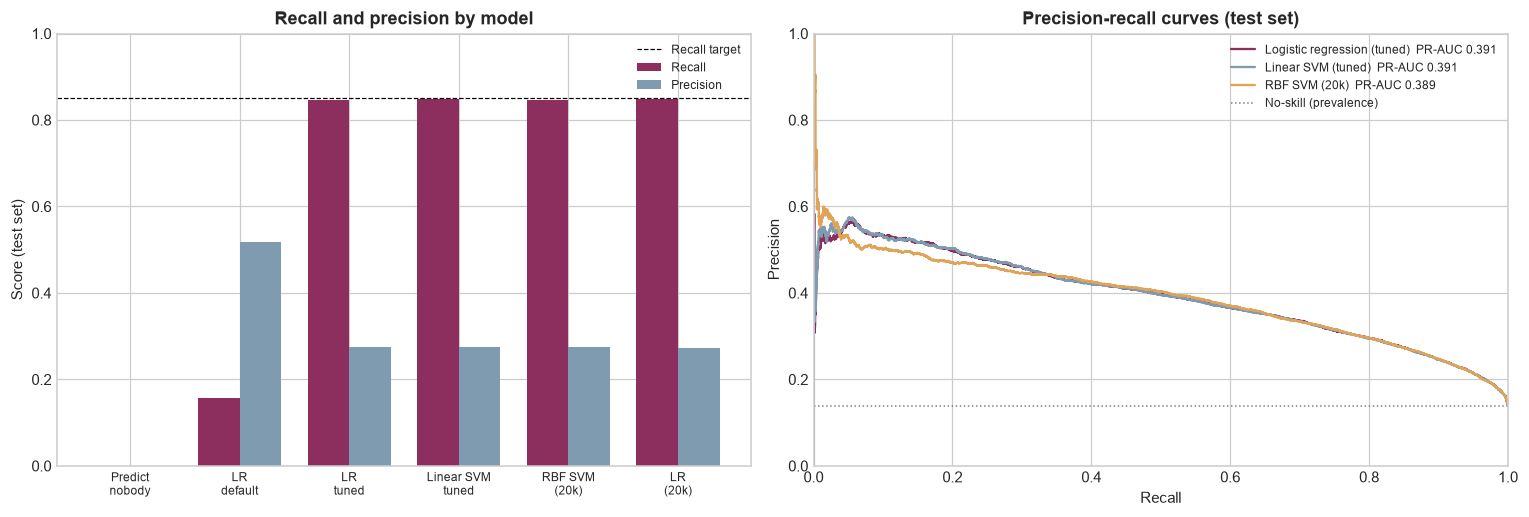

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

short = {"Predict nobody has diabetes": "Predict\nnobody",
         "Logistic regression, default (0.50)": "LR\ndefault",
         "Logistic regression, tuned for recall": "LR\ntuned",
         "Linear SVM, tuned for recall": "Linear SVM\ntuned",
         "RBF SVM (20k rows), tuned for recall": "RBF SVM\n(20k)",
         "Logistic regression (20k rows), tuned for recall": "LR\n(20k)"}
labels = [short.get(m, m) for m in comparison.index]
xpos, w = np.arange(len(labels)), 0.38
axes[0].bar(xpos - w/2, comparison["Recall"], w, label="Recall", color=C_DIA)
axes[0].bar(xpos + w/2, comparison["Precision"], w, label="Precision", color=C_NO)
axes[0].axhline(TARGET_RECALL, color="black", ls="--", lw=0.8, label="Recall target")
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Score (test set)")
axes[0].set_title("Recall and precision by model")
axes[0].legend(frameon=False, fontsize=8)

for name, score, color in [("Logistic regression (tuned)", p_lr, C_DIA),
                           ("Linear SVM (tuned)", d_svm, C_NO),
                           ("RBF SVM (20k)", d_rbf, C_PRE)]:
    prec, rec, _ = precision_recall_curve(y_test, score)
    axes[1].plot(rec, prec, color=color,
                 label=f"{name}  PR-AUC {average_precision_score(y_test, score):.3f}")
axes[1].axhline(y_test.mean(), color="grey", ls=":", lw=1, label="No-skill (prevalence)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_title("Precision-recall curves (test set)")
axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

findfont: Failed to find font weight 600, now using 700.


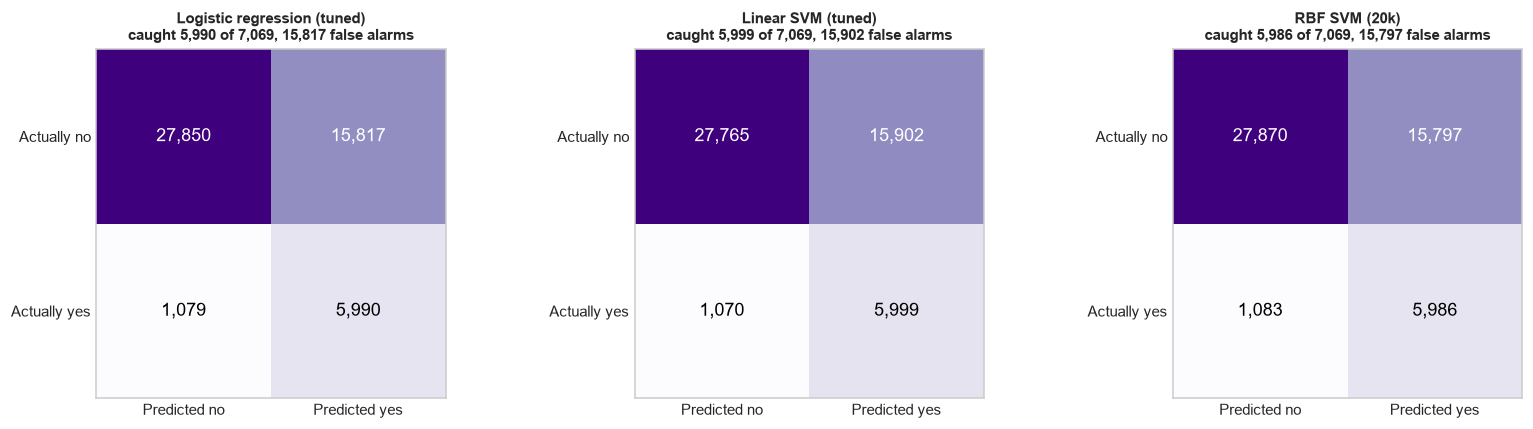

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, score, thr) in zip(axes, [("Logistic regression (tuned)", p_lr, lr_thr),
                                         ("Linear SVM (tuned)", d_svm, svm_thr),
                                         ("RBF SVM (20k)", d_rbf, rbf_thr)]):
    cm = confusion_matrix(y_test, (score >= thr).astype(int))
    ax.imshow(cm, cmap="Purples")
    ax.grid(False)
    for (r, c), v in np.ndenumerate(cm):
        ax.text(c, r, f"{v:,}", ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black", fontsize=12)
    ax.set_xticks([0, 1], ["Predicted no", "Predicted yes"])
    ax.set_yticks([0, 1], ["Actually no", "Actually yes"])
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\ncaught {tp:,} of {tp+fn:,}, {fp:,} false alarms", fontsize=10)
plt.tight_layout()
plt.show()

# 6. Model Performance and Parameter Tuning

## What we built

| Model | Training data | Parameters tuned (CV on F2) | Chosen |
|---|---|---|---|
| Logistic regression | 202,944 rows (80%) | `C`, L1/L2 penalty, class weight (5-fold) | `C` = 0.01, L2, diabetic weight 9.27 |
| Linear SVM (`LinearSVC`) | 202,944 rows | `C`, class weight (5-fold) | `C` = 0.001, diabetic weight 9.27 |
| RBF-kernel SVM | 20,000-row stratified subsample | `C`, `gamma` (3-fold) | `C` = 1, `gamma` = 0.01 |

Every model was then given its own decision threshold, set on out-of-fold
training predictions to reach 85% recall. All models were scored once on the
same 50,736-row test set.

## How well each model performs (test set)

| Model | Accuracy | Recall | Precision | F2 | ROC-AUC | PR-AUC |
|---|---|---|---|---|---|---|
| Predict nobody has diabetes | 0.861 | 0.000 | 0.000 | 0.000 | 0.500 | 0.139 |
| Logistic regression, default | 0.862 | 0.157 | 0.518 | 0.183 | 0.818 | 0.393 |
| **Logistic regression, tuned** | 0.667 | **0.847** | 0.275 | **0.598** | 0.818 | 0.391 |
| **Linear SVM, tuned** | 0.665 | **0.849** | 0.274 | **0.598** | 0.818 | 0.391 |
| RBF SVM (20k rows) | 0.667 | 0.847 | 0.275 | 0.598 | 0.818 | 0.389 |
| Logistic regression (same 20k rows) | 0.664 | 0.848 | 0.273 | 0.596 | 0.817 | 0.390 |

The default model looks accurate but is not useful. At 86.2% accuracy it
barely beats the 86.1% of predicting "no diabetes" for everyone, and it finds
only 15.7% of diabetics. This is why accuracy is not our target metric.

Tuning raised recall from 15.7% to about 85% for every model.
The cost is precision: about 27% of people flagged are diagnosed diabetics, so
there are roughly 2.6 false alarms per diabetic caught. Accuracy falls to
about 67%, below the do-nothing floor. That drop is expected and acceptable:
we deliberately trade many cheap false alarms for fewer costly missed cases.

**What the parameter adjustments did:**

* For the linear models, class weight was the only parameter that mattered.
  In the linear SVM grid, "balanced" weighting gave 77% cross-validated recall,
  and doubling it gave 85.5%. 
* `C` and the penalty type made no difference for the linear models. For a
  given class weight, every `C` from 0.001 to 10 gave the same F2 to three
  decimals, and L1 and L2 tied. 
* The RBF SVM did need tuning. A large `gamma` hurt at
  every `C`, and combining large `C` with large `gamma` overfit badly:
  cross-validated F2 fell to 0.39–0.47, compared with 0.596 for the best setting
  (`C` = 1, `gamma` = 0.01). The winning settings give a smooth boundary, the
  closest the RBF kernel gets to a linear one.

No model beats the others on ranking quality. ROC-AUC is 0.817–0.818 for
all of them, and the precision-recall curves in Section 5 lie on top of each
other. Tuning moves each model along the same tradeoff curve; it does not
improve the curve itself.

# 7. Advantages of Each Model: Accuracy and Efficiency

## Prediction performance: a tie

At the 85% recall target, logistic regression and the linear SVM have the same
precision (0.275 vs. 0.274), the same F2 (0.598), and the same ROC-AUC (0.818).
The RBF SVM trained on 20,000 rows lands in the same place: precision 0.275,
F2 0.598, ROC-AUC 0.818. Its PR-AUC (0.389) is no better than logistic
regression trained on the same 20,000 rows (0.390) or on all the data (0.391).
Neither model type offers superior prediction accuracy on this data. The
limit is the information in the 18 survey answers, not the choice of model.

The fact that the curved RBF boundary gained nothing is itself a finding: the
diabetes signal here is close to linear (more risk factors, higher risk),
so a flexible boundary has nothing extra to find.

## Advantages of each

**Logistic regression**
* Outputs probabilities, so the threshold means something and risk scores can be communicated.
* The weights convert to odds ratios, which makes interpretation straightforward.
* Fast, stable, and uses every row in the fit.

**Linear SVM**
* Maximizes the margin, and its hinge loss ignores points that are already
  classified correctly with room to spare. That makes it less sensitive to
  easy, extreme cases.
* Same speed as logistic regression here. 
* Downsides: the output is a distance, not a probability which means converting it needs a
  separate calibration step, and the weights have no odds-ratio meaning.

**RBF-kernel SVM**
* Can learn curved boundaries and interactions without us creating them by
  hand, which would help if the signal were non-linear.
* Downsides: slow to train and predict at this scale, has more parameters to
  tune, and produces no interpretable weights.

**Recommendation:** tuned logistic regression. It matches the SVMs on
accuracy, it is among the fastest, and it gives probabilities and interpretable
weights.

# 8. Interpreting the Logistic Regression Weights

Because every feature was standardized, each weight is the change in the
log-odds of diabetes for a one-standard-deviation increase in that feature,
holding the others fixed. Exponentiating a weight gives an odds ratio: a
value of 1.5 means the odds of diabetes are 50% higher per SD. We also convert
the weights back to per-unit odds ratios which are easier to explain.

In [19]:
clf = lr_best.named_steps["clf"]
scaler = lr_best.named_steps["scale"]

weights = pd.DataFrame({
    "Weight (per SD)": clf.coef_[0],
    "Odds ratio per SD": np.exp(clf.coef_[0]),
    "Feature SD": scaler.scale_,
    "Odds ratio per unit": np.exp(clf.coef_[0] / scaler.scale_),
}, index=X_train.columns)
weights["|Weight|"] = weights["Weight (per SD)"].abs()
weights = weights.sort_values("|Weight|", ascending=False)
weights["Rank"] = np.arange(1, len(weights) + 1)
weights.drop(columns="|Weight|").round(3)

,Weight (per SD),Odds ratio per SD,Feature SD,Odds ratio per unit,Rank
GenHlth,0.633,1.883,1.068,1.808,1
BMI,0.508,1.663,6.598,1.080,2
Age,0.482,1.619,3.051,1.171,3
HighBP,0.372,1.450,0.495,2.119,4
HighChol,0.295,1.343,0.494,1.816,5
HvyAlcoholConsump,-0.173,0.841,0.229,0.471,6
Sex,0.138,1.148,0.497,1.320,7
Income,-0.116,0.890,2.073,0.945,8
HeartDiseaseorAttack,0.076,1.079,0.292,1.298,9
PhysHlth,-0.053,0.948,8.726,0.994,10


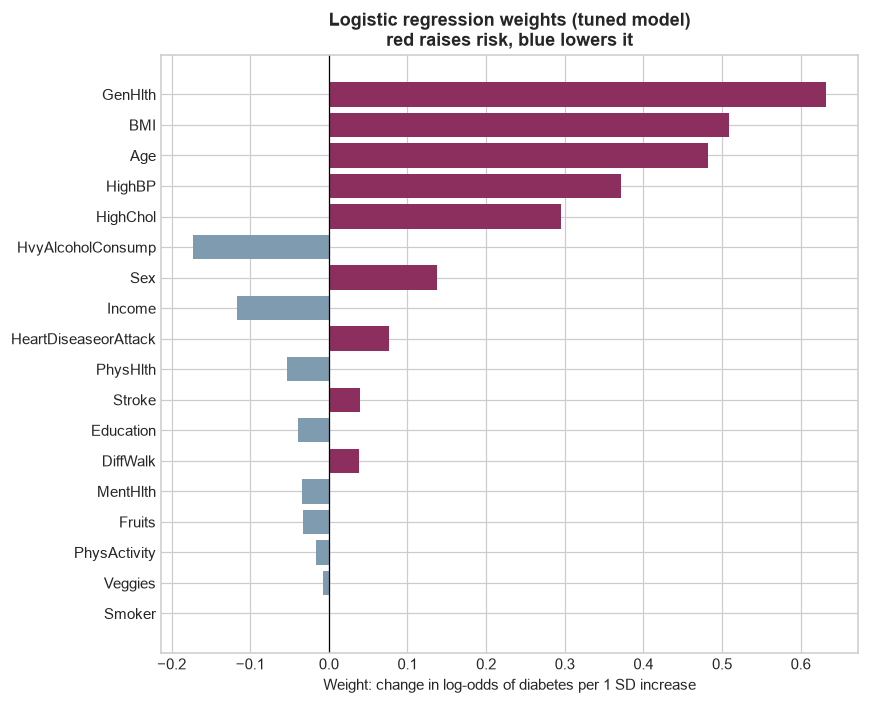

In [20]:
w_plot = weights["Weight (per SD)"].iloc[::-1]
fig, ax = plt.subplots(figsize=(8, 6.5))
ax.barh(w_plot.index, w_plot.values, color=np.where(w_plot.values > 0, C_DIA, C_NO))
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Weight: change in log-odds of diabetes per 1 SD increase")
ax.set_title("Logistic regression weights (tuned model)\nred raises risk, blue lowers it")
plt.tight_layout()
plt.show()

### Are the weights stable?

Several features overlap. `GenHlth`, `PhysHlth`, and `DiffWalk` all measure
physical health, and `Income` and `Education` both measure socioeconomic
status. When features are correlated, the model can shift weight between them,
so an individual weight can be less reliable than it looks. To check, we refit
the model on 20 bootstrap resamples of the training data and see how much each
weight moves. We also compare it with the linear SVM's weights, which come from
a different loss function.

In [21]:
rng = np.random.default_rng(SEED)
boot = []
for b in range(20):
    idx = rng.integers(0, len(X_train), len(X_train))
    m = Pipeline([("scale", StandardScaler()),
                  ("clf", LogisticRegression(solver="liblinear", max_iter=2000,
                                             **{k.split("__")[1]: v for k, v in
                                                lr_grid.best_params_.items()}))])
    m.fit(X_train.iloc[idx], y_train.iloc[idx])
    boot.append(m.named_steps["clf"].coef_[0])
boot = pd.DataFrame(boot, columns=X_train.columns)

svm_w = pd.Series(svm_best.named_steps["clf"].coef_[0], index=X_train.columns)

stability = pd.DataFrame({
    "LR weight": weights["Weight (per SD)"],
    "Bootstrap 95% low": boot.quantile(0.025),
    "Bootstrap 95% high": boot.quantile(0.975),
    "Linear SVM weight (rescaled)": svm_w * (weights["Weight (per SD)"].abs().sum()
                                             / svm_w.abs().sum()),
}).loc[weights.index]
stability["Sign stable?"] = np.sign(stability["Bootstrap 95% low"]) == np.sign(stability["Bootstrap 95% high"])
print(f"Rank agreement between LR and linear SVM weights (Spearman): "
      f"{weights['Weight (per SD)'].abs().rank().corr(svm_w.abs().rank(), method='spearman'):.3f}")
stability.round(3)

Rank agreement between LR and linear SVM weights (Spearman): 0.973


,LR weight,Bootstrap 95% low,Bootstrap 95% high,Linear SVM weight (rescaled),Sign stable?
GenHlth,0.633,0.617,0.653,0.633,True
BMI,0.508,0.498,0.521,0.471,True
Age,0.482,0.470,0.493,0.480,True
HighBP,0.372,0.359,0.382,0.418,True
HighChol,0.295,0.281,0.302,0.301,True
HvyAlcoholConsump,-0.173,-0.188,-0.152,-0.176,True
Sex,0.138,0.124,0.148,0.136,True
Income,-0.116,-0.135,-0.100,-0.116,True
HeartDiseaseorAttack,0.076,0.063,0.086,0.064,True
PhysHlth,-0.053,-0.063,-0.031,-0.066,True


In [22]:
# Correlations among the overlapping groups, to support the discussion below
X_train[["GenHlth", "PhysHlth", "DiffWalk", "MentHlth", "Income", "Education", "Age"]].corr().round(2)

,GenHlth,PhysHlth,DiffWalk,MentHlth,Income,Education,Age
GenHlth,1.000,0.520,0.460,0.300,-0.370,-0.280,0.150
PhysHlth,0.520,1.000,0.480,0.350,-0.270,-0.160,0.100
DiffWalk,0.460,0.480,1.000,0.230,-0.320,-0.190,0.200
MentHlth,0.300,0.350,0.230,1.000,-0.210,-0.100,-0.090
Income,-0.370,-0.270,-0.320,-0.210,1.000,0.450,-0.130
Education,-0.280,-0.160,-0.190,-0.100,0.450,1.000,-0.100
Age,0.150,0.100,0.200,-0.090,-0.130,-0.100,1.000


### Interpretation

The weights are trustworthy. Every weight's 95% bootstrap interval is
narrow, and all but two keep the same sign in every resample. The two
exceptions, `Veggies` and `Smoker`, have intervals that include zero, meaning no
detectable effect. The linear SVM, trained with a different loss function, ranks
the features almost identically (Spearman correlation 0.97). The ranking is a
property of the data, not of one model.

Five features carry most of the weight:

| Rank | Feature | Odds ratio | Meaning |
|---|---|---|---|
| 1 | `GenHlth` | 1.81 per step | Each step worse on the 1–5 self-rated health scale raises the odds of diabetes by 81%. Going from "excellent" to "poor" (4 steps) multiplies them by about 10.7. |
| 2 | `BMI` | 1.08 per point | Each BMI point adds 8%, so 10 points (for example 25 → 35) roughly **doubles** the odds (1.08¹⁰ ≈ 2.2). |
| 3 | `Age` | 1.17 per 5-year bracket | From age 18–24 to 80+ (12 brackets), the odds rise by a factor of about 6.6. |
| 4 | `HighBP` | 2.12 | High blood pressure doubles the odds. |
| 5 | `HighChol` | 1.82 | High cholesterol raises them by 82%. |

These five match our EDA's Cramér's V ranking. 

`GenHlth` is partly a consequence of
diabetes, not only a cause. People who already know they are diabetic, and
live with its complications, rate their health lower. The survey is
cross-sectional, so the model cannot tell
cause from effect. `GenHlth` is a strong predictor but not a risk factor to
intervene on.

**Small but meaningful effects:**

* `Sex` (1.32): men have 32% higher odds, consistent with men developing type 2
  diabetes at lower BMI.
* `HeartDiseaseorAttack` (1.30) and `Stroke` (1.23): cardiovascular disease
  shares causes with diabetes and is also one of its complications.
* `Income` (0.945 per bracket): from the lowest to the highest bracket, the
  odds fall by about a third (0.945⁷ ≈ 0.67). This reflects diet, stress, and
  access to healthy food, over and above what BMI captures. `Education` (0.96)
  points the same way but is weaker, because it overlaps with income
  (correlation 0.45).

**Two weights that look backwards, and why:**

* `HvyAlcoholConsump` (0.47): heavy drinkers have half the odds of diabetes.
  Alcohol does not protect against diabetes. The likely explanation is reverse
  causation: people diagnosed with diabetes are told to cut back on drinking, so
  diagnosed diabetics are under-represented among current heavy drinkers. This
  is a clear example of a cross-sectional survey producing an association that
  should not be read as causal.
* `PhysHlth` has a small negative weight, and `DiffWalk` a weight near zero,
  even though both are higher among diabetics in the raw data. Both correlate
  with `GenHlth` (0.52 and 0.46). Once general health is in the model, most of
  their information is already counted, and the leftover weight is small. This
  is a warning against reading each weight in isolation: it shows what a feature
  adds after the others are accounted for, not how important the feature is
  on its own.


# 9. What the Support Vectors Tell Us

Support vectors are the training points that define the SVM's boundary: points
on or inside the margin, including misclassified ones. Points far from the
boundary on the correct side have no effect on the model. So the support vectors
are the hard, ambiguous cases, and their number and profile show how
separable the classes are.

We look at them in two ways:

1. RBF SVM: scikit-learn stores its support vectors directly
   (`support_`, `n_support_`).
2. Linear SVM: `LinearSVC` does not store them, but they are exactly the
   training points with margin `y·f(x) ≤ 1` (with `y` coded as ±1), so we can
   compute them for the full training set.

In [23]:
rbf_svc = rbf_best.named_steps["clf"]
sv_idx = rbf_svc.support_
n_neg, n_pos = rbf_svc.n_support_

print("RBF SVM (20,000-row subsample)")
print(f"  support vectors: {len(sv_idx):,} of {len(X_sub):,} training rows "
      f"({100*len(sv_idx)/len(X_sub):.1f}%)")
print(f"  non-diabetic SVs: {n_neg:,} of {(y_sub==0).sum():,} non-diabetics "
      f"({100*n_neg/(y_sub==0).sum():.1f}%)")
print(f"  diabetic SVs:     {n_pos:,} of {(y_sub==1).sum():,} diabetics "
      f"({100*n_pos/(y_sub==1).sum():.1f}%)")

# Bounded SVs (alpha at the C limit) are on the wrong side of the margin
alpha = np.abs(rbf_svc.dual_coef_[0])
cw = rbf_svc.class_weight_
limit = rbf_svc.C * np.where(y_sub.values[sv_idx] == 1, cw[1], cw[0])
bounded = np.isclose(alpha, limit)
print(f"  inside the margin or misclassified (alpha at its limit): {bounded.sum():,} "
      f"({100*bounded.mean():.1f}% of SVs)")

# Linear SVM on the full training set
y_pm = np.where(y_train == 1, 1, -1)
margin = y_pm * svm_best.decision_function(X_train)
lin_sv = margin <= 1
print("\nLinear SVM (full training set)")
print(f"  support vectors (margin <= 1): {lin_sv.sum():,} of {len(X_train):,} "
      f"({100*lin_sv.mean():.1f}%)")
print(f"  misclassified (margin < 0):    {(margin < 0).sum():,}")

RBF SVM (20,000-row subsample)
  support vectors: 11,458 of 20,000 training rows (57.3%)
  non-diabetic SVs: 9,790 of 17,213 non-diabetics (56.9%)
  diabetic SVs:     1,668 of 2,787 diabetics (59.8%)
  inside the margin or misclassified (alpha at its limit): 11,258 (98.3% of SVs)

Linear SVM (full training set)
  support vectors (margin <= 1): 191,451 of 202,944 (94.3%)
  misclassified (margin < 0):    68,809


### Does the share of support vectors depend on `C`?

A large share of support vectors could simply come from a small `C` (a wide,
soft margin). To rule that out, we refit the linear SVM across the `C` grid and
count the support vectors each time.

In [24]:
best_cw = svm_grid.best_params_["clf__class_weight"]   # tuned class weight from 4.1
y_pm = np.where(y_train == 1, 1, -1)                     # labels coded as -1 / +1

rows = []
for C in [0.001, 0.01, 0.1, 1]:
    m = Pipeline([("scale", StandardScaler()),
                  ("clf", LinearSVC(C=C, class_weight=best_cw, dual=False,
                                    max_iter=5000, random_state=SEED))]).fit(X_train, y_train)
    mg = y_pm * m.decision_function(X_train)
    rows.append({"C": C, "Support vectors": int((mg <= 1).sum()),
                 "Share of training rows": (mg <= 1).mean(),
                 "Test ROC-AUC": roc_auc_score(y_test, m.decision_function(X_test))})
pd.DataFrame(rows).set_index("C").round(4)

,Support vectors,Share of training rows,Test ROC-AUC
C,,,
0.001,191451,0.943,0.818
0.010,191379,0.943,0.818
0.100,191368,0.943,0.818
1.000,191368,0.943,0.818


### Who are the support vectors?

Compare the average profile of the support vectors with the
non-support vectors in each class. If the support vectors are the hard cases,
diabetic support vectors should look healthier than typical diabetics, and
non-diabetic support vectors should look less health than typical
non-diabetics.

In [25]:
KEY = ["GenHlth", "BMI", "Age", "HighBP", "HighChol", "DiffWalk", "HeartDiseaseorAttack",
       "PhysHlth", "Income"]
Xs = X_sub.reset_index(drop=True)
ys = y_sub.reset_index(drop=True)
is_sv = pd.Series(False, index=Xs.index)
is_sv.iloc[sv_idx] = True

profile = (Xs[KEY].assign(Diabetic=ys.map({0: "No", 1: "Yes"}),
                          Group=np.where(is_sv, "Support vector", "Not a support vector"))
           .groupby(["Diabetic", "Group"]).mean())
profile.insert(0, "n", Xs.assign(Diabetic=ys.map({0: "No", 1: "Yes"}),
                                 Group=np.where(is_sv, "Support vector", "Not a support vector"))
                       .groupby(["Diabetic", "Group"]).size())
profile.round(2)

n  GenHlth    BMI   Age  HighBP  HighChol  DiffWalk  HeartDiseaseorAttack  PhysHlth  Income
Diabetic Group                                                                                                               
No       Not a support vector  7423    1.740 25.540 6.200   0.080     0.150     0.010                 0.000     1.170   6.850
         Support vector        9790    2.870 29.540 9.030   0.600     0.560     0.230                 0.130     5.430   5.690
Yes      Not a support vector  1119    3.810 35.300 9.850   0.940     0.830     0.540                 0.360    11.140   4.650
         Support vector        1668    2.920 29.720 9.060   0.620     0.570     0.240                 0.150     5.900   5.600

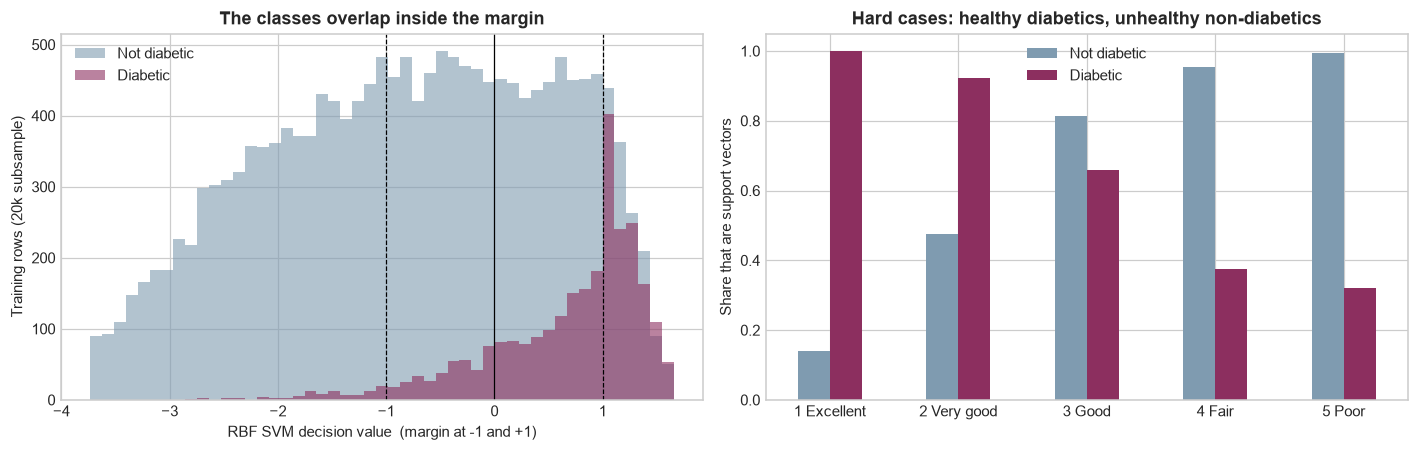

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Left: where support vectors sit in the decision value distribution
d_sub = rbf_best.decision_function(X_sub)
bins = np.linspace(np.percentile(d_sub, 0.5), np.percentile(d_sub, 99.5), 50)
axes[0].hist(d_sub[ys == 0], bins=bins, alpha=0.6, color=C_NO, label="Not diabetic")
axes[0].hist(d_sub[ys == 1], bins=bins, alpha=0.6, color=C_DIA, label="Diabetic")
for v in (-1, 0, 1):
    axes[0].axvline(v, color="black", ls="--" if v else "-", lw=0.8)
axes[0].set_xlabel("RBF SVM decision value  (margin at -1 and +1)")
axes[0].set_ylabel("Training rows (20k subsample)")
axes[0].set_title("The classes overlap inside the margin")
axes[0].legend(frameon=False)

# Right: share of rows that are support vectors, by self-rated general health
share = (pd.DataFrame({"GenHlth": Xs["GenHlth"], "SV": is_sv, "Diabetic": ys})
         .groupby(["GenHlth", "Diabetic"])["SV"].mean().unstack())
share.index = ["1 Excellent", "2 Very good", "3 Good", "4 Fair", "5 Poor"][:len(share)]
share.plot(kind="bar", ax=axes[1], color=[C_NO, C_DIA], rot=0)
axes[1].set_ylabel("Share that are support vectors")
axes[1].set_title("Hard cases: healthy diabetics, unhealthy non-diabetics")
axes[1].legend(["Not diabetic", "Diabetic"], frameon=False)
plt.tight_layout()
plt.show()

### Interpretation

Most of the training data are support vectors, which means the classes overlap
heavily. In a well-separated problem, only a small fraction of points sit near
the boundary. 

Here:

* RBF SVM: 11,458 of 20,000 rows (57%) are support vectors, and 98.3% of
  those are inside the margin or misclassified rather than resting exactly on
  its edge.
* Linear SVM: 191,451 of 202,944 rows (94%) fall on or inside the margin.
  The separate table shows this share stays at 94% for every `C` from 0.001
  to 1. The large number of support vectors is not an artifact of a soft
  margin: there is no wide, clean gap between diabetics and non-diabetics to
  find.

This agrees with our EDA, where the two classes overlapped almost completely in
the PCA projection. It also explains why no model reached a ROC-AUC above 0.82.

The support vectors from both classes look alike. 

In the profile table:

| | GenHlth | BMI | Age bracket | HighBP | HighChol |
|---|---|---|---|---|---|
| Non-diabetic support vectors | 2.87 | 29.5 | 9.03 | 60% | 56% |
| Diabetic support vectors | 2.92 | 29.7 | 9.06 | 62% | 57% |

On every key feature, the two groups are nearly indistinguishable. The model
cannot separate them because, on these 18 survey answers, they are the same
kind of person: middle-aged to older, overweight, with average self-rated
health.

**The rows that are not support vectors are the easy cases.**

* Non-diabetics the model is sure about are younger (age bracket 6.2, about
  50–54), lean (BMI 25.5), and rarely have high blood pressure (8%).
* Diabetics the model is sure about are the textbook case: poor general health
  (3.81), BMI 35.3, 94% with high blood pressure. Only 1,119 of 2,787 diabetics
  (40%) look this clear-cut. The other 60% are support vectors.

The right-hand chart shows this by general health. Every diabetic who rates
their health "excellent" is a support vector, and so is nearly every
non-diabetic who rates it "poor". The hard cases are healthy-looking diabetics
and unhealthy-looking non-diabetics.

**What this tells us about the data:**

1. Many non-diabetic support vectors are probably undiagnosed diabetics.
   They share the diabetic risk profile but have no diagnosis. Our target is
   diagnosed diabetes, so some of these "false alarms" may be real cases. The
   precision we measured is a lower bound. 
2. Some diabetic support vectors are likely well-managed diabetics. People
   who have lost weight, control their blood pressure, and feel healthy after
   diagnosis no longer look like the textbook profile.
3. Better models will not fix this; better features would. The overlap is in
   the data itself. Separating these groups would need clinical measurements
   such as blood glucose or HbA1c, which a phone survey does not collect.